# Suicide and Depression Text Classification

Introduction

In this project, we aim to build a machine learning model that predicts whether a text expresses suicidal ideation or not. The dataset consists of user generated posts, some labeled as suicidal and others as non suicidal.

Suicide and depression are serious global health concerns, and analyzing online text can provide valuable insights for early detection and prevention. By using traditional machine learning techniques, we can identify linguistic patterns and features that differentiate between high risk and safe content.

We will perform the following steps in this notebook:
- Load and clean the dataset
- Explore and visualize the data
- Train and evaluate machine learning model

Let’s get started

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# import the necessary libraries

In [ ]:
Data = pd.read_csv('Suicide_Detection.csv')
Data.head()

# load the dataset

FileNotFoundError: [Errno 2] No such file or directory: 'suicide_and_depression_detection/Suicide_Detection.csv'

# Clean and Preprocess The Data 

In [3]:
Data.drop(columns='Unnamed: 0',inplace=True)

# drop unnecessary column

In [4]:
def clean_text(text):
    text = text.lower()
    cleaned = ''.join(c for c in text if c.isalpha() or c.isspace())
    return cleaned

Data['text'] = Data['text'].apply(clean_text)

# clean the data

In [5]:
Data.isnull().sum().sum()

# check for missing values

0

In [6]:
Data.duplicated().sum()

# check for duplicates values

211

In [7]:
Data.drop_duplicates(inplace=True)

In [8]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

Data['class'] = encoder.fit_transform(Data['class'])

# preprocess the data

# EDA

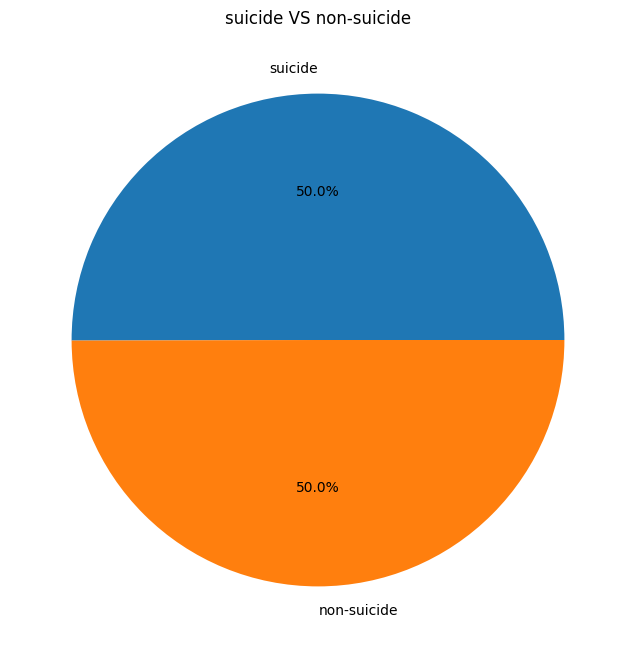

In [9]:
value = Data['class'].value_counts()

labels = ['suicide','non-suicide']

plt.figure(figsize=(8,8))
plt.pie(value,autopct='%1.1f%%',labels=labels)
plt.title('suicide VS non-suicide')
plt.show()

# explore the data with pieplot

In [10]:
x = Data['text']
y = Data['class']

In [11]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.3,random_state=42)

# split the data

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(stop_words='english')

x_train_vec = vec.fit_transform(x_train)
x_test_vec = vec.transform(x_test)

# convert the data form text to numbers

# Naive Bayes

In [13]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(x_train_vec,y_train)

# train the model

MultinomialNB()

In [14]:
y_pred = nb.predict(x_test_vec)

In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
print(f"""The Accuracy : {accuracy *100:.2f}%""")

# evaluate the model with accuracy score

The Accuracy : 88.69%


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

# evaluate the model with classification report

              precision    recall  f1-score   support

           0       0.97      0.80      0.88     34775
           1       0.83      0.98      0.90     34784

    accuracy                           0.89     69559
   macro avg       0.90      0.89      0.89     69559
weighted avg       0.90      0.89      0.89     69559



In [17]:
print(f"""Train Score : {nb.score(x_train_vec,y_train) * 100:.2f}%""")
print(f"""Test Score : {nb.score(x_test_vec,y_test) * 100:.2f}%""")

# display training and test accuracy

Train Score : 90.34%
Test Score : 88.69%


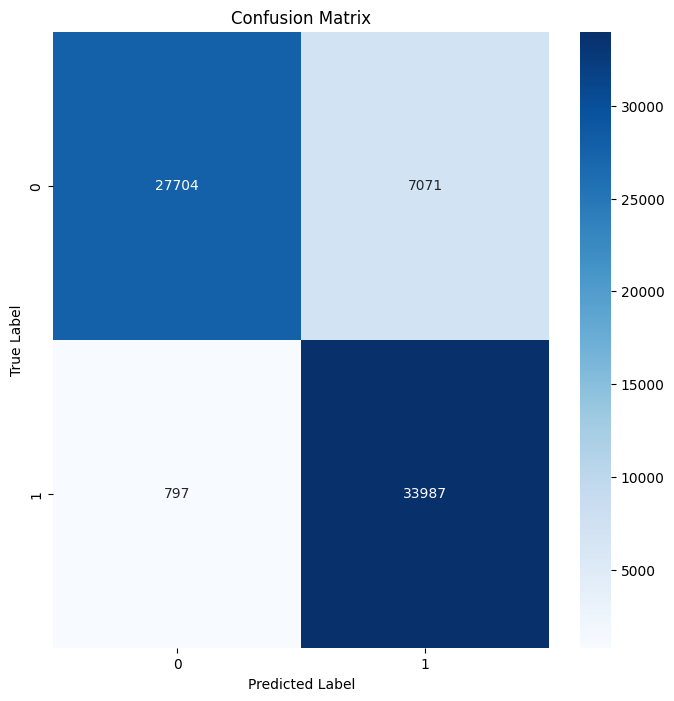

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# evaluate the model with confusion matrix

# Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(x_train_vec,y_train)

# train the model

LogisticRegression()

In [20]:
y_pred = lr.predict(x_test_vec)

In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
print(f"""The Accuracy : {accuracy *100:.2f}%""")

# evaluate the model with accuracy score

The Accuracy : 93.42%


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

# evaluate the model with classification report

              precision    recall  f1-score   support

           0       0.93      0.94      0.93     34775
           1       0.94      0.93      0.93     34784

    accuracy                           0.93     69559
   macro avg       0.93      0.93      0.93     69559
weighted avg       0.93      0.93      0.93     69559



In [23]:
print(f"""Train Score : {lr.score(x_train_vec,y_train) * 100:.2f}%""")
print(f"""Test Score : {lr.score(x_test_vec,y_test) * 100:.2f}%""")

# display training and test accuracy

Train Score : 94.29%
Test Score : 93.42%


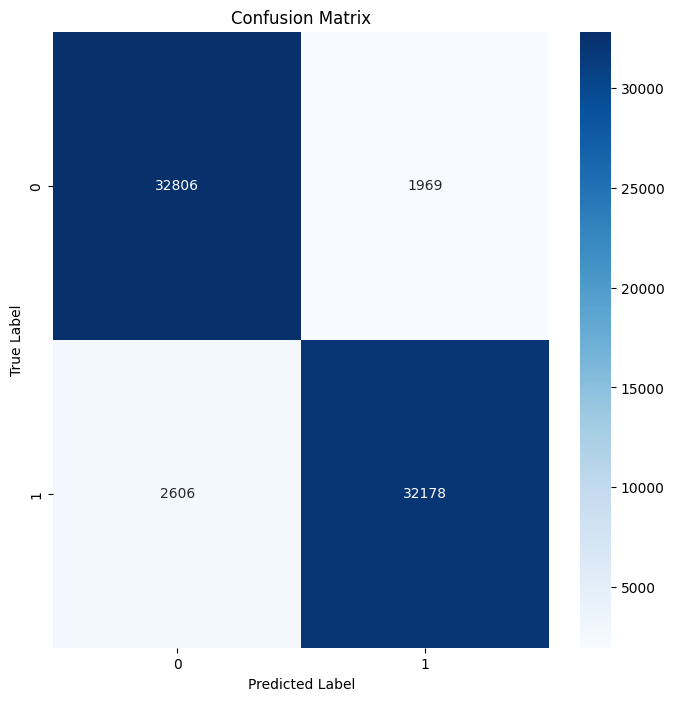

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# evaluate the model with confusion matrix

# LightGBM

In [25]:
from lightgbm import LGBMClassifier

light = LGBMClassifier(n_estimators=100, learning_rate=0.1)
light.fit(x_train_vec, y_train)

[LightGBM] [Info] Number of positive: 81234, number of negative: 81070
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 21.063343 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 856920
[LightGBM] [Info] Number of data points in the train set: 162304, number of used features: 13831
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500505 -> initscore=0.002021
[LightGBM] [Info] Start training from score 0.002021


LGBMClassifier()

In [26]:
y_pred = light.predict(x_test_vec)

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
print(f"""The Accuracy : {accuracy *100:.2f}%""")

# evaluate the model with accuracy score

The Accuracy : 91.33%


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

# evaluate the model with classification report

              precision    recall  f1-score   support

           0       0.90      0.93      0.91     34775
           1       0.93      0.90      0.91     34784

    accuracy                           0.91     69559
   macro avg       0.91      0.91      0.91     69559
weighted avg       0.91      0.91      0.91     69559



In [29]:
print(f"""Train Score : {light.score(x_train_vec,y_train) * 100:.2f}%""")
print(f"""Test Score : {light.score(x_test_vec,y_test) * 100:.2f}%""")

# display training and test accuracy

Train Score : 91.79%
Test Score : 91.33%


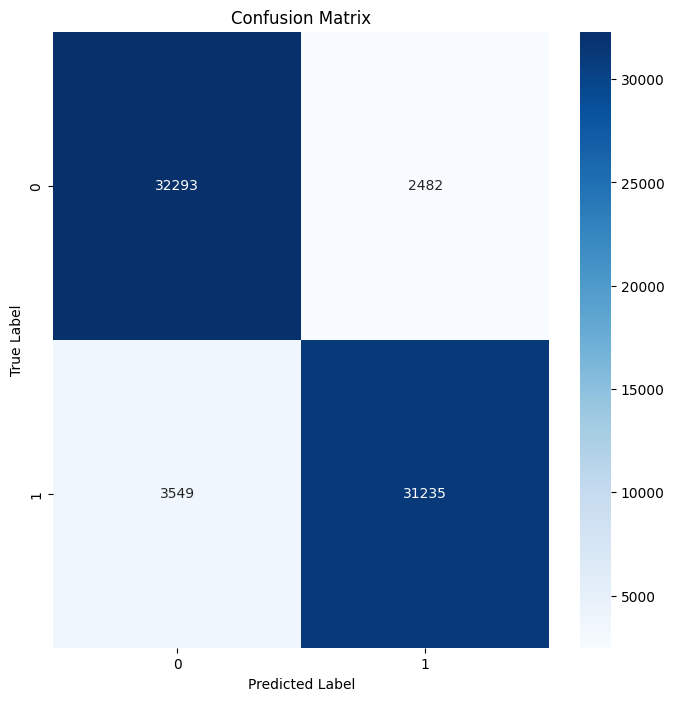

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# evaluate the model with confusion matrix